## Imports

In [5]:
%pip install scipy


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import scipy.io
import numpy as np
import math
from sklearn import linear_model 
from scipy import linalg
from sklearn import preprocessing as preproc # load preprocessing function
import matplotlib.pyplot as plt 
import matplotlib.colors as colors
from sklearn.model_selection import KFold


# seaborn can be used to "prettify" default matplotlib plots by importing and setting as default
import seaborn as sns
sns.set() # Set searborn as default

## Load dataset

In [7]:
mat = scipy.io.loadmat('sand.mat')

X = mat['X']
y = mat['Y']

[n,p] = X.shape

### 1 Apply Least angle regression and selection (LARS) for the p >> n sand data set (X: data matrix with 59 observations and 2016 features, y: the measured moisture content in percent for each sand sample). Find a suitable solution using:

>(a) The Cp statistic. Consider whether the Cp-statistic makes sense in this case (p > n). Why? Why not?

>> (i) Hint: What happens to your estimate of the noise in the data?

In [8]:
# Estimate the noise of the data
# Calculate an unbiased OLS estimate using linalg.lstsq
betas, res, rnk, s = linalg.lstsq(X, y)
y_ols = X@betas
# Using the mean squared error (MSE) of a low bias model (OLS) as the estimate for the noise variance
s2 = np.mean((y-y_ols)**2)  
print(s2)


1.1155991082895205e-24


>(b) Using Cross-validation. Remember to center y and normalize X, but do it inside
the cross validation!

In [20]:
def centerData(data):
    
    mu = np.mean(data,axis=0)
    data = data - mu
    
    return data, mu


def normalizeData(X):
    '''
    Function for normalizing the columns (variables) of a data matrix to unit length.
    Returns the normalized data and the euclidian lenghts of the variables 
    
    Input  (X) --------> The data matrix to be normalized 
    Output (X_pre)-----> The normalized data matrix 
    Output (d) --------> Array with the euclidian lenghts of the variables 
    '''
    d = np.linalg.norm(X,axis=0,ord=2)  # d is the the L2 norms of the variables
    d[d==0]=1                           # Avoid dividing by zero if column L2 norm is 0 
    X_pre = X / d                       # Normalize the data with the euclidian lengths
    return X_pre,d                      # Return normalized data and the euclidian lengths


# Set up cross validation like you did last week
CV = 5 # if K = n leave-one-out, you may try different numbers
kf = KFold(n_splits=CV)

# Set a suitable range of features that can be given to LARS as n_nonzero_coefs 
stop = n-math.ceil(n/CV)
K = range(stop)

Err_tr = np.zeros((CV,len(K)))
Err_tst = np.zeros((CV, len(K))) 
for i, (train_index, test_index) in enumerate(kf.split(X)):
    # NOTE: If you normalize outside the CV loop the data implicitly carry information of the test data
    # We should perform CV "the right way" and keep test data unseen.
    
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index].ravel(), y[test_index].ravel() # ravel collapses the array, ie dim(x,1) to (x,)

    print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

    y_train, mu = centerData(y_train) # center y
    y_test = y_test - mu

    X_train, mu = centerData(X_train) # center X
    X_test = X_test - mu

    X_train, d = normalizeData(X_train) # normalize X
    X_test = X_test / d # normalize test data with the same sigma as the training data
    
    for j in K:
    # compute all LARS solutions inside each fold 
        print(j)
        reg = linear_model.Lars(n_nonzero_coefs=j+1, fit_path = False, fit_intercept = False, verbose = True)
        reg.fit(X_train,y_train)
        beta = reg.coef_.ravel()
        
        # Predict with this model, and find error
        YhatTr = X_train @ beta
        YhatTest = X_test @ beta
        
        Err_tr[i-1, j] = np.mean((YhatTr-y_train)**2) # training error
        Err_tst[i-1, j] = np.mean((YhatTest-y_test)**2) # test error
        # Predict with this model, and find both training and test error

err_tr = np.mean(Err_tr, axis=0) # mean training error over the CV folds
err_tst = np.mean(Err_tst, axis=0) # mean test error over the CV folds
err_ste = np.std(Err_tst, axis=0)/np.sqrt(CV) # Note: we divide with sqrt(n) to get the standard error as opposed to the standard deviation

(47, 2016) (47,) (12, 2016) (12,)
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
(47, 2016) (47,) (12, 2016) (12,)
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
(47, 2016) (47,) (12, 2016) (12,)
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
(47, 2016) (47,) (12, 2016) (12,)
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
(48, 2016) (48,) (11, 2016) (11,)
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46


In [25]:
# Compute Cp-statistic, assumption n > p

# run LARS on all data and and vary the nonzero coefs from 0 to p. save the betas for Cp

# calculate Cp for each number of nonzero coefs

Betas = np.zeros((p, n))
for j in range(n):
    reg = linear_model.Lars(n_nonzero_coefs=j+1)
    reg.fit(X,y)
    Betas[:,i] = reg.coef_


Cp = np.zeros((len(K)))
for j in range(len(K)):
    Yhat = X @ Betas[:,K[j]]
    Cp[j] = np.mean(((y-Yhat)**2)) + 2*K[j]/n*s2

print(Cp)

[2.46863203e+01 2.46863203e+01 2.46863203e+01 2.46863203e+01
 1.01140926e+07 2.46863203e+01 2.46863203e+01 2.46863203e+01
 2.46863203e+01 2.46863203e+01 2.46863203e+01 2.46863203e+01
 2.46863203e+01 2.46863203e+01 2.46863203e+01 2.46863203e+01
 2.46863203e+01 2.46863203e+01 2.46863203e+01 2.46863203e+01
 2.46863203e+01 2.46863203e+01 2.46863203e+01 2.46863203e+01
 2.46863203e+01 2.46863203e+01 2.46863203e+01 2.46863203e+01
 2.46863203e+01 2.46863203e+01 2.46863203e+01 2.46863203e+01
 2.46863203e+01 2.46863203e+01 2.46863203e+01 2.46863203e+01
 2.46863203e+01 2.46863203e+01 2.46863203e+01 2.46863203e+01
 2.46863203e+01 2.46863203e+01 2.46863203e+01 2.46863203e+01
 2.46863203e+01 2.46863203e+01 2.46863203e+01]


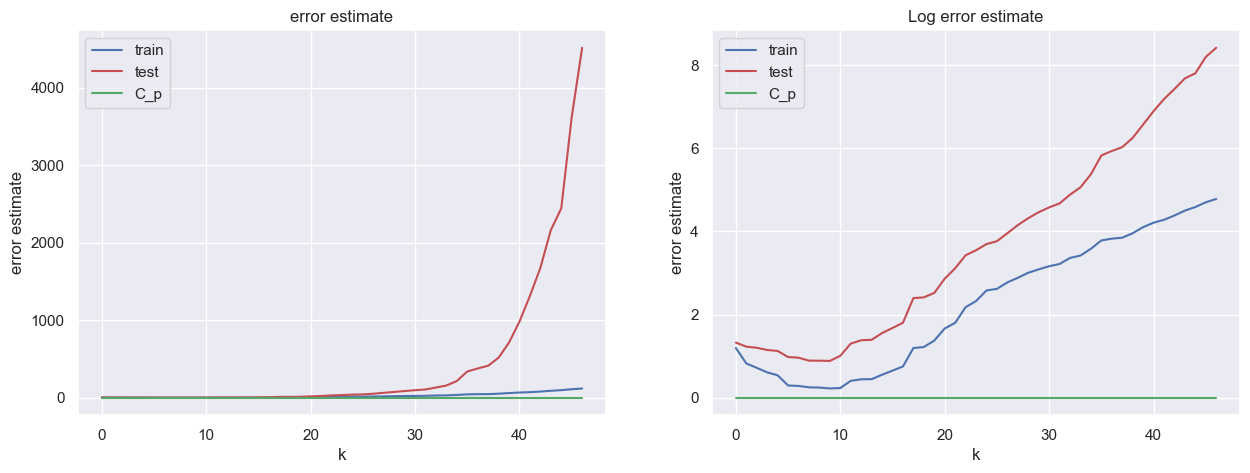

In [26]:
fig, ax = plt.subplots(1,2, figsize=(15,5))    
ax[0].plot(K, err_tr, 'b', label='train')
ax[0].plot(K, err_tst, 'r', label='test')
ax[0].plot(K, Cp/1e27, 'g', label= 'C_p') # scale to put in same plot
ax[0].legend()
ax[0].set_xlabel('k')
ax[0].set_ylabel('error estimate')
ax[0].set_title("error estimate")

ax[1].plot(K, np.log(err_tr), 'b', label='train')
ax[1].plot(K, np.log(err_tst), 'r', label='test')
ax[1].plot(K, Cp/1e27, 'g', label= 'C_p') # scale to put in same plot
ax[1].legend()
ax[1].set_xlabel('k')
ax[1].set_ylabel('error estimate')
ax[1].set_title("Log error estimate")
plt.show()

Conclusion:

